# Future Star Model Development Report

In this notebook i tried to follow a clear step-by-step workflow.

Order:
1. Prepare model data from cleaned Model B dataset
2. Train Logistic Regression for DF, FW, GK, MF
3. Train Random Forest for DF, FW, GK, MF
4. Train Gradient Boosting for DF, FW, GK, MF
5. Compare all models
6. Select best model per position and rank players by `star_probability`

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
data_path = Path(r"C:\Users\User\Desktop\projects\Portfolio\Pet-projects\moneyball-like\data\model_ready\tm_fbref_merged_ready.csv")
feature_path = Path(r"C:\Users\User\Desktop\projects\Portfolio\Pet-projects\moneyball-like\data\model_ready\model_2_all_features_by_position.json")

raw = pd.read_csv(data_path)
with open(feature_path, "r", encoding="utf-8") as file:
    feature_map = json.load(file)

all_json_features = sorted({feature for feature_list in feature_map.values() for feature in feature_list})

display(Markdown("## Raw Data Overview"))
display(pd.DataFrame({
    "rows": [len(raw)],
    "columns": [raw.shape[1]],
    "season_min": [int(raw["season_end_year"].min())],
    "season_max": [int(raw["season_end_year"].max())],
    "position_groups": [", ".join(sorted(raw["position_group_model"].dropna().unique().tolist()))],
    "json_feature_counts": [str({key: len(value) for key, value in feature_map.items()})],
}))


## Raw Data Overview

,rows,columns,season_min,season_max,position_groups,json_feature_counts
0,12882,132,2020,2025,"DF, FW, GK, MF","{'DF': 51, 'FW': 45, 'GK': 63, 'MF': 29}"


## Step 1. Data Preparation

I build the modeling table using only information from period `t`.

Main preparation steps:
- sort by `player_id` and `season`
- create `market_value_t1` with shift(-1) per player
- keep rows where `market_value_t1` exists
- compute `log_value_t`, `log_value_t1`, and `growth`
- define `star = 1` when growth is in top 20% inside season + position
- keep Model B JSON metrics and metadata
- remove future-leak columns from features
- split data into DF, FW, GK, MF tables

Note: source data has no direct `player_id`, so I extract it from the Transfermarkt URL.

In [3]:
base = raw.copy()
base["player_id"] = base["player_url"].str.extract(r"/spieler/(\d+)")
base["season"] = base["season_end_year"]
base["league"] = base["comp"]
base["position_group"] = base["position_group_model"]
base["market_value"] = base["target_market_value"]
base["age_squared"] = base["age"] ** 2

for column in [feature for feature in all_json_features if feature.startswith("comp_")]:
    base[column] = (base["league"] == column.replace("comp_", "", 1)).astype(int)

for column in [feature for feature in all_json_features if feature.startswith("nation_")]:
    base[column] = (base["nation"] == column.replace("nation_", "", 1)).astype(int)

for column in all_json_features:
    if column not in base.columns:
        base[column] = 0.0

base = base.sort_values(["player_id", "season"]).copy()
base["market_value_t1"] = base.groupby("player_id")["market_value"].shift(-1)
base["next_season"] = base.groupby("player_id")["season"].shift(-1)
base = base[base["market_value_t1"].notna()].copy()

base["log_value_t"] = np.log(base["market_value"])
base["log_value_t1"] = np.log(base["market_value_t1"])
base["growth"] = base["log_value_t1"] - base["log_value_t"]
base["growth_p80"] = base.groupby(["season", "position_group"])["growth"].transform("quantile", 0.8)
base["star"] = (base["growth"] >= base["growth_p80"]).astype(int)

metadata_columns = ["player_id", "player", "fbref_player_name", "player_url", "fbref_url", "tm_url", "name_key", "squad", "league", "nation", "method", "age", "season", "position_group", "league_strength", "market_value", "market_value_t1", "log_value_t", "log_value_t1", "growth", "growth_p80", "star", "next_season"]
model_metadata_features = ["age", "season", "league_strength", "market_value", "log_value_t"]
final_modeling_table = base[metadata_columns + [column for column in all_json_features if column not in metadata_columns]].copy()

feature_columns_by_position = {}
position_tables = {}
train_sets = {}
test_sets = {}
X_by_position = {}
y_by_position = {}
X_train_by_position = {}
y_train_by_position = {}
X_test_by_position = {}
y_test_by_position = {}

for position_group, feature_list in feature_map.items():
    feature_columns_by_position[position_group] = model_metadata_features + [column for column in feature_list if column not in model_metadata_features]
    selected_columns = metadata_columns + [column for column in feature_columns_by_position[position_group] if column not in metadata_columns]
    position_tables[position_group] = final_modeling_table.loc[final_modeling_table["position_group"] == position_group, selected_columns].copy()
    latest_test_season = int(position_tables[position_group]["season"].max())
    train_sets[position_group] = position_tables[position_group][position_tables[position_group]["season"] < latest_test_season].copy()
    test_sets[position_group] = position_tables[position_group][position_tables[position_group]["season"] == latest_test_season].copy()
    X_by_position[position_group] = position_tables[position_group][feature_columns_by_position[position_group]].copy()
    y_by_position[position_group] = position_tables[position_group]["star"].copy()
    X_train_by_position[position_group] = train_sets[position_group][feature_columns_by_position[position_group]].copy()
    y_train_by_position[position_group] = train_sets[position_group]["star"].copy()
    X_test_by_position[position_group] = test_sets[position_group][feature_columns_by_position[position_group]].copy()
    y_test_by_position[position_group] = test_sets[position_group]["star"].copy()

modeling_table_df = position_tables["DF"].copy()
modeling_table_fw = position_tables["FW"].copy()
modeling_table_gk = position_tables["GK"].copy()
modeling_table_mf = position_tables["MF"].copy()

prep_summary = pd.DataFrame({
    "position_group": list(position_tables.keys()),
    "rows": [len(position_tables[key]) for key in position_tables],
    "feature_count": [len(feature_columns_by_position[key]) for key in position_tables],
    "train_rows": [len(train_sets[key]) for key in position_tables],
    "test_rows": [len(test_sets[key]) for key in position_tables],
    "test_season": [int(test_sets[key]["season"].max()) for key in position_tables],
})

display(Markdown("### Final Modeling Table"))
display(final_modeling_table.head())
display(prep_summary)


### Final Modeling Table

,player_id,player,fbref_player_name,player_url,fbref_url,tm_url,name_key,squad,league,nation,method,age,season,position_group,league_strength,market_value,market_value_t1,log_value_t,log_value_t1,growth,growth_p80,star,next_season,2crdy_p90,aerial_win_pct,age_squared,ast_per,att_3rd_tackles_p90,att_3rd_touches_p90,att_challenges_p90,att_long_p90,att_medium_p90,att_passes_p90,att_pen_touches_p90,att_short_p90,avgdist_sweeper,avglen_goal,avrg_dist_per_carry,avrg_prg_dist_pass,blocks_outcomes_p90,ck_pass_p90,cmp_launched_p90,cmp_percent_launched,cmp_percent_long,cmp_percent_medium,cmp_percent_short,cmp_percent_total,comp_La Liga,comp_Ligue 1,comp_Premier League,comp_Serie A,cpa_carries_p90,crdy_p90,crs_p90,crs_pass_p90,cs_percent,def_3rd_tackles_p90,def_3rd_touches_p90,def_pen_touches_p90,dis_carries_p90,dist_standard,err_p90,final_third_p90,fk_goals_p90,fk_pass_p90,fk_standard_p90,fld_p90,fls_p90,g_minus_pk_per,g_per_sh_standard,g_per_sot_standard,gls_per,int_p90,live_pass_p90,lost_aerial_p90,mid_3rd_tackles_p90,mid_3rd_touches_p90,mis_carries_p90,nation_ESP,nation_ITA,npxg_per,npxg_per_sh_expected,off_outcomes_p90,off_p90,og_p90,on_minus_off_team_success_xg,ong_team_success_p90,onga_team_success_p90,onxg_team_success_xg_p90,pass_blocks_p90,pass_cmp_pct,pk_p90,pk_success_rate,pkcon_p90,pkwon_p90,plus_per_minus_team_success,ppa_p90,ppm_team_success,prgc_carries_p90,recov_p90,save_percent,saves_p90,sh_blocks_p90,sot_percent_standard,stp_crosses_p90,stp_percent_crosses,succ_percent_take,sw_pass_p90,tb_pass_p90,ti_pass_p90,tkl_tackles_p90,tklw_win_rate,touches_touches_p90,won_aerial_p90,xg_per,xg_xag_per,xgplus_per_minus_90_team_success_xg,xgplus_per_minus_team_success_xg
4523,1000136,Gorka Rivera Alonso,Gorka Rivera Alonso,https://www.transfermarkt.com/gorka-rivera/pro...,https://fbref.com/en/players/f1124008/Gorka-Ri...,https://www.transfermarkt.com/gorka-rivera/pro...,gorka rivera alonso,Getafe,La Liga,ESP,Method 2: Jul-Sep,17.0000,2023,DF,84.5000,"100,000.0000","100,000.0000",11.5129,11.5129,0.0000,0.2231,0,"2,024.0000",0.0000,0.0000,289.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,NaN,NaN,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,NaN,0.0000,0.0000,NaN,0.0000,0.0000,NaN,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN
12492,10003,Wes Morgan,Wes Morgan,https://www.transfermarkt.com/wes-morgan/profi...,https://fbref.com/en/players/80c31c97/Wes-Morgan,https://www.transfermarkt.com/wes-morgan/profi...,wes morgan,Leicester City,Premier League,JAM,Method 3: Apr-May,35.0000,2020,DF,91.2000,"1,200,000.0000","400,000.0000",13.9978,12.8992,-1.0986,0.4055,0,"2,021.0000",0.0000,0.5588,"1,225.0000",0.0000,0.0000,1.4450,0.6193,5.1606,30.5505,0.0000,0.8257,12.5917,NaN,NaN,4.0227,4.3403,0.2064,0.0000,0.0000,NaN,84.0000,94.6000,93.4000,92.4000,0,0,1,0,0.0000,0.0000,0.0000,0.0000,NaN,0.6193,27.0413,4.1284,0.2064,10.0000,0.0000,0.6193,0.0000,0.6193,0.0000,0.2064,0.8257,0.0000,0.0000,0.0000,0.0000,1.4450,49.9541,3.0963,0.2064,31.9954,0.2064,0,0,0.1100,0.1400,0.4128,0.0000,0.0000,0.8800,1.8578,1.2385,2.1881,0.4128,0.9244,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000,2.2700,0.2064,3.3028,NaN,0.0000,0.6193,50.0000,0.0000,NaN,100.0000,0.0000,0.0000,0.0000,0.8257,0.2500,60.2752,3.9220,0.1100,0.1100,1.2100,5.9000
12542,100131,William Carvalho,William Carvalho,https://www.transfermarkt.com/william-carvalho...,https://fbref.com/en/players/dee86451/William-...,https://www.transfermarkt.com/william-carvalho...,william carvalho,Betis,La Liga,POR,Method 3: Apr-May,27.0000,2020,MF,84.5000,"16,000,000.0000","15,000,000.0000",16.5881,16.5236,-0.0645,0.4615,0,"2,021.0000",0.0000,0.7037,729.0000,0.0000,0.1009,12.0067,1.41

,position_group,rows,feature_count,train_rows,test_rows,test_season
0,DF,3188,56,2657,531,2024
1,FW,1175,50,995,180,2024
2,GK,1131,68,957,174,2024
3,MF,2060,34,1737,323,2024


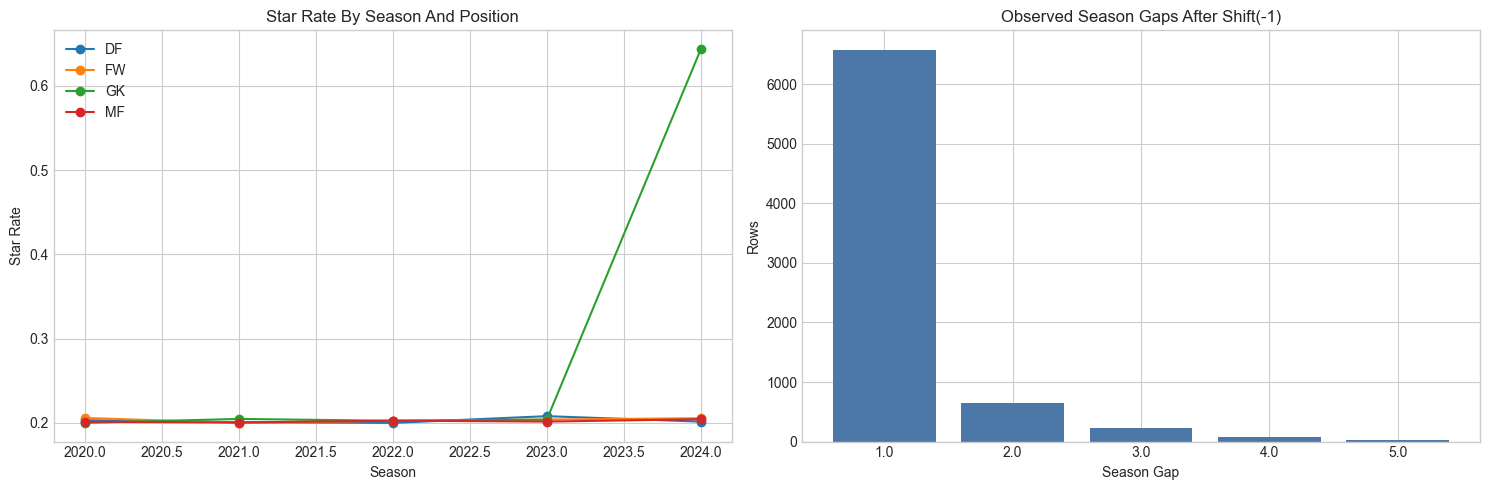

The latest held-out transition is `2024 -> 2025` for all four position groups. Goalkeepers in 2024 have many zero-growth ties, so the `>= 80th percentile` rule produces a much higher positive rate there than 20 percent.

In [4]:
target_balance = base.groupby(["season", "position_group"])["star"].mean().reset_index()
season_gap = base.assign(season_gap=base["next_season"] - base["season"]).groupby("season_gap").size().reset_index(name="rows")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for position_group in sorted(target_balance["position_group"].unique()):
    subset = target_balance[target_balance["position_group"] == position_group]
    axes[0].plot(subset["season"], subset["star"], marker="o", label=position_group)
axes[0].set_title("Star Rate By Season And Position")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Star Rate")
axes[0].legend()

axes[1].bar(season_gap["season_gap"].astype(str), season_gap["rows"], color="#4C78A8")
axes[1].set_title("Observed Season Gaps After Shift(-1)")
axes[1].set_xlabel("Season Gap")
axes[1].set_ylabel("Rows")
plt.tight_layout()
plt.show()

display(Markdown("The latest held-out transition is `2024 -> 2025` for all four position groups. Goalkeepers in 2024 have many zero-growth ties, so the `>= 80th percentile` rule produces a much higher positive rate there than 20 percent."))


## Step 2. Model 1: Logistic Regression

This is the first baseline model.
Because features have different scales, I use:
- median imputation
- standard scaling
- logistic regression

Outputs in this section:
- one results table for all positions
- ROC curves by position
- top absolute standardized coefficients

In [5]:
logistic_results = []
logistic_models = {}
logistic_probabilities = {}
logistic_coefficients = {}

for position_group in sorted(position_tables.keys()):
    logistic_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ])
    logistic_model.fit(X_train_by_position[position_group], y_train_by_position[position_group])
    logistic_probabilities[position_group] = pd.Series(logistic_model.predict_proba(X_test_by_position[position_group])[:, 1], index=test_sets[position_group].index)
    logistic_models[position_group] = logistic_model

    k_for_precision = int(y_test_by_position[position_group].sum())
    logistic_ranked_test = test_sets[position_group][["player_id", "player", "star"]].copy()
    logistic_ranked_test["star_probability"] = logistic_probabilities[position_group]
    logistic_ranked_test = logistic_ranked_test.sort_values("star_probability", ascending=False)

    logistic_results.append({
        "position_group": position_group,
        "model": "Logistic Regression",
        "test_season": int(test_sets[position_group]["season"].max()),
        "n_train": len(train_sets[position_group]),
        "n_test": len(test_sets[position_group]),
        "test_star_rate": y_test_by_position[position_group].mean(),
        "k_for_precision": k_for_precision,
        "auc": roc_auc_score(y_test_by_position[position_group], logistic_probabilities[position_group]),
        "precision_at_k": logistic_ranked_test.head(k_for_precision)["star"].mean(),
    })

    logistic_coefficients[position_group] = pd.DataFrame({
        "feature": feature_columns_by_position[position_group],
        "coefficient": logistic_model.named_steps["model"].coef_[0],
    }).assign(abs_coefficient=lambda frame: frame["coefficient"].abs()).sort_values("abs_coefficient", ascending=False)

logistic_results_df = pd.DataFrame(logistic_results).sort_values("position_group").reset_index(drop=True)
display(logistic_results_df)


,position_group,model,test_season,n_train,n_test,test_star_rate,k_for_precision,auc,precision_at_k
0,DF,Logistic Regression,2024,2657,531,0.2015,107,0.7951,0.4393
1,FW,Logistic Regression,2024,995,180,0.2056,37,0.7224,0.4054
2,GK,Logistic Regression,2024,957,174,0.6437,112,0.6744,0.7054
3,MF,Logistic Regression,2024,1737,323,0.2043,66,0.7812,0.4545


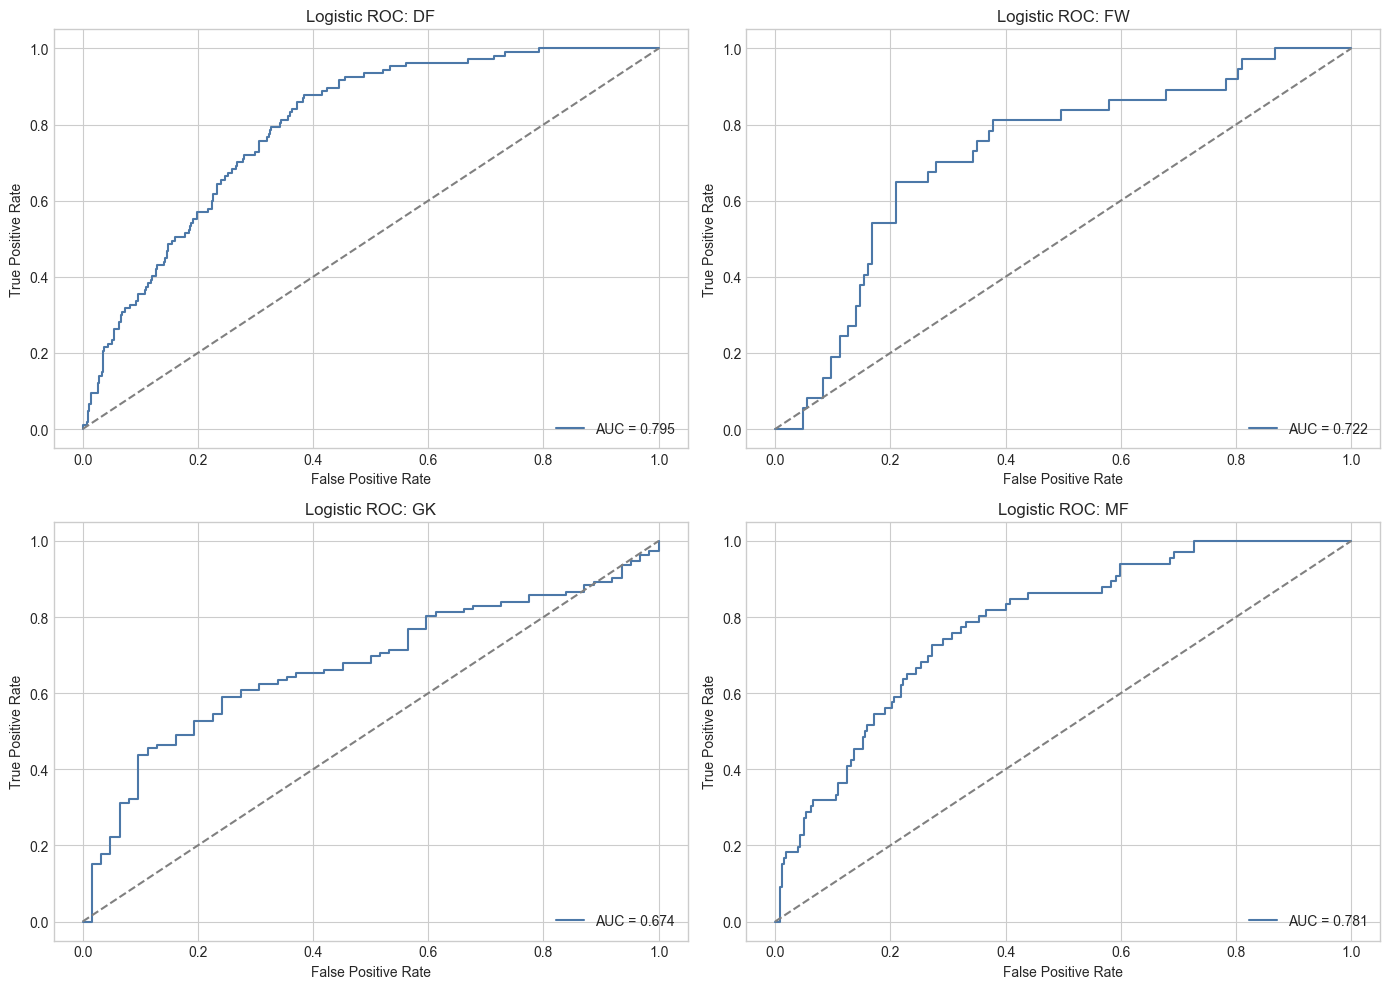

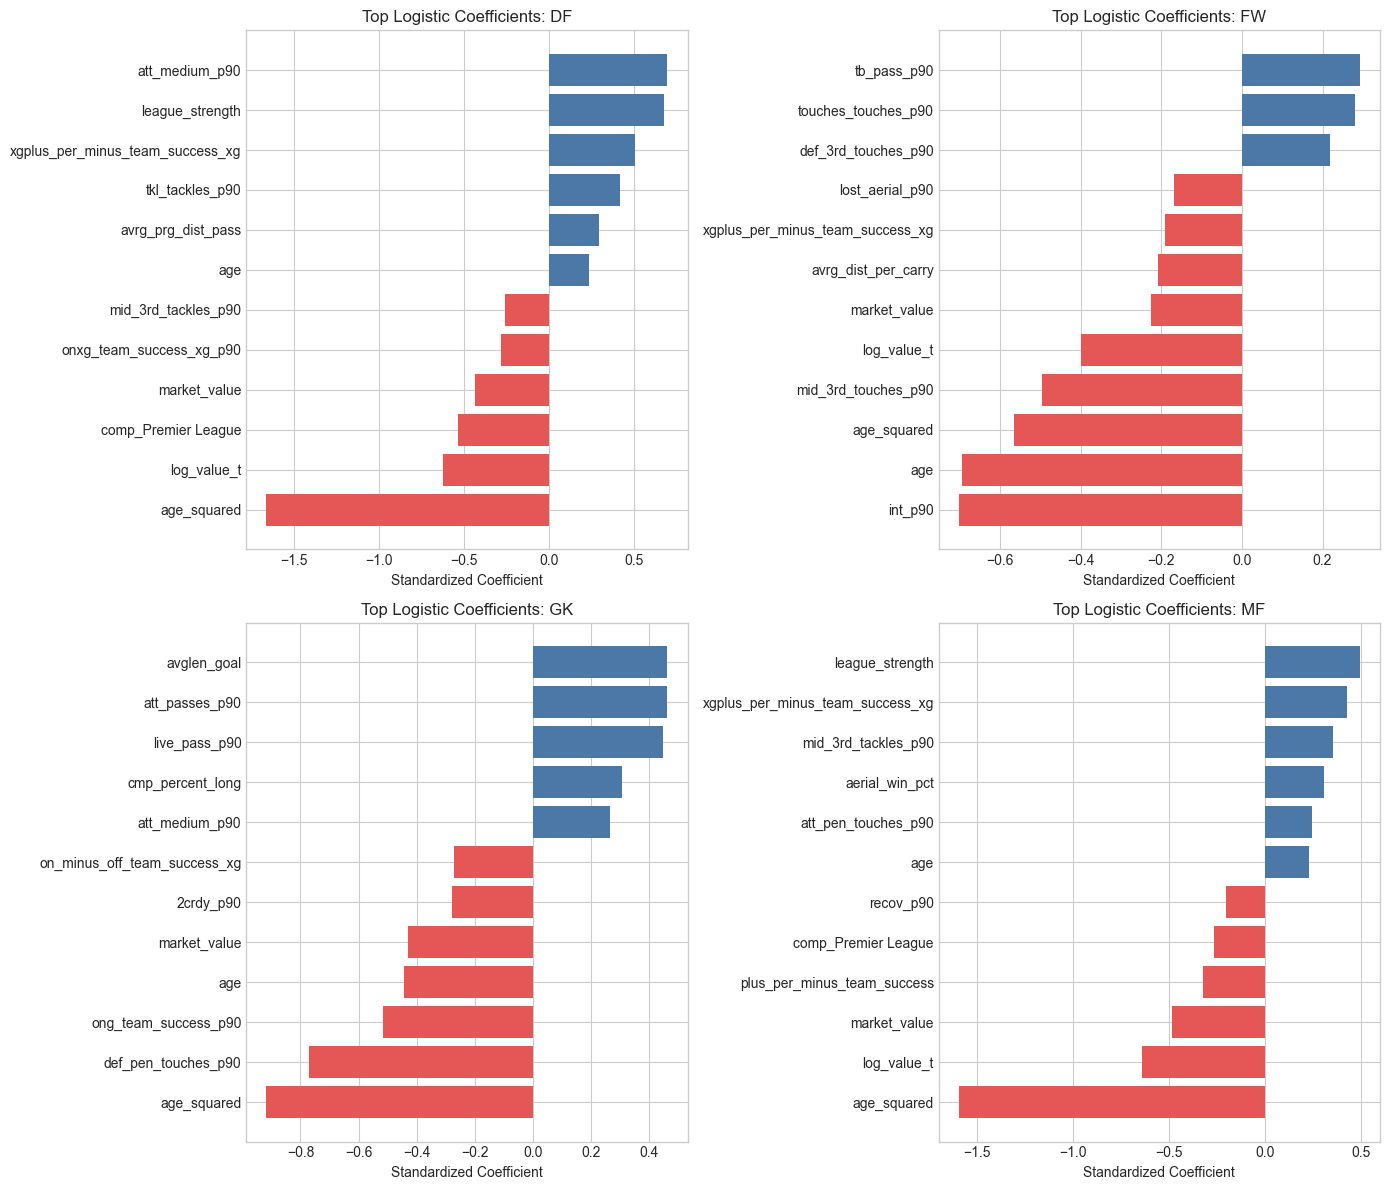

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, position_group in zip(axes.flatten(), sorted(position_tables.keys())):
    fpr, tpr, _ = roc_curve(y_test_by_position[position_group], logistic_probabilities[position_group])
    auc_value = roc_auc_score(y_test_by_position[position_group], logistic_probabilities[position_group])
    axis.plot(fpr, tpr, color="#4C78A8", label=f"AUC = {auc_value:.3f}")
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray")
    axis.set_title(f"Logistic ROC: {position_group}")
    axis.set_xlabel("False Positive Rate")
    axis.set_ylabel("True Positive Rate")
    axis.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for axis, position_group in zip(axes.flatten(), sorted(position_tables.keys())):
    top_coef = logistic_coefficients[position_group].head(12).sort_values("coefficient")
    colors = ["#E45756" if value < 0 else "#4C78A8" for value in top_coef["coefficient"]]
    axis.barh(top_coef["feature"], top_coef["coefficient"], color=colors)
    axis.set_title(f"Top Logistic Coefficients: {position_group}")
    axis.set_xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()


## Step 3. Model 2: Random Forest

This is the second baseline model.
Tree models do not need scaling, so I use:
- median imputation
- random forest classifier

Outputs in this section:
- one results table for all positions
- ROC curves by position
- top feature importances

In [7]:
rf_results = []
rf_models = {}
rf_probabilities = {}
rf_importances = {}

for position_group in sorted(position_tables.keys()):
    rf_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=400, min_samples_leaf=3, random_state=42, n_jobs=1)),
    ])
    rf_model.fit(X_train_by_position[position_group], y_train_by_position[position_group])
    rf_probabilities[position_group] = pd.Series(rf_model.predict_proba(X_test_by_position[position_group])[:, 1], index=test_sets[position_group].index)
    rf_models[position_group] = rf_model

    k_for_precision = int(y_test_by_position[position_group].sum())
    rf_ranked_test = test_sets[position_group][["player_id", "player", "star"]].copy()
    rf_ranked_test["star_probability"] = rf_probabilities[position_group]
    rf_ranked_test = rf_ranked_test.sort_values("star_probability", ascending=False)

    rf_results.append({
        "position_group": position_group,
        "model": "Random Forest",
        "test_season": int(test_sets[position_group]["season"].max()),
        "n_train": len(train_sets[position_group]),
        "n_test": len(test_sets[position_group]),
        "test_star_rate": y_test_by_position[position_group].mean(),
        "k_for_precision": k_for_precision,
        "auc": roc_auc_score(y_test_by_position[position_group], rf_probabilities[position_group]),
        "precision_at_k": rf_ranked_test.head(k_for_precision)["star"].mean(),
    })

    rf_importances[position_group] = pd.DataFrame({
        "feature": feature_columns_by_position[position_group],
        "importance": rf_model.named_steps["model"].feature_importances_,
    }).sort_values("importance", ascending=False)

rf_results_df = pd.DataFrame(rf_results).sort_values("position_group").reset_index(drop=True)
display(rf_results_df)


,position_group,model,test_season,n_train,n_test,test_star_rate,k_for_precision,auc,precision_at_k
0,DF,Random Forest,2024,2657,531,0.2015,107,0.7402,0.3925
1,FW,Random Forest,2024,995,180,0.2056,37,0.7263,0.4324
2,GK,Random Forest,2024,957,174,0.6437,112,0.7141,0.7679
3,MF,Random Forest,2024,1737,323,0.2043,66,0.7721,0.5303


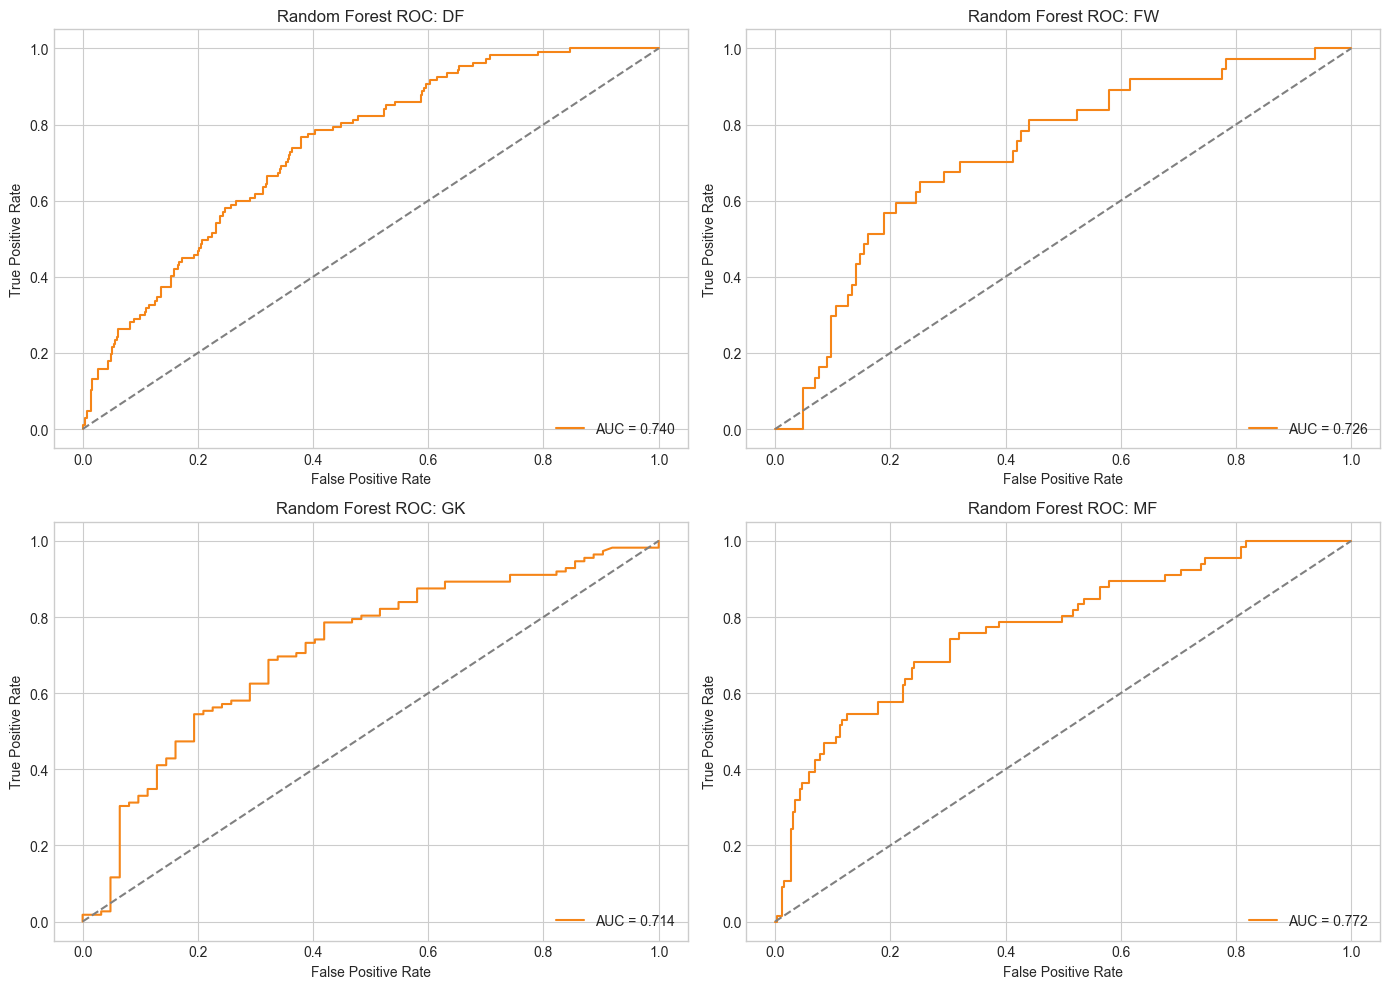

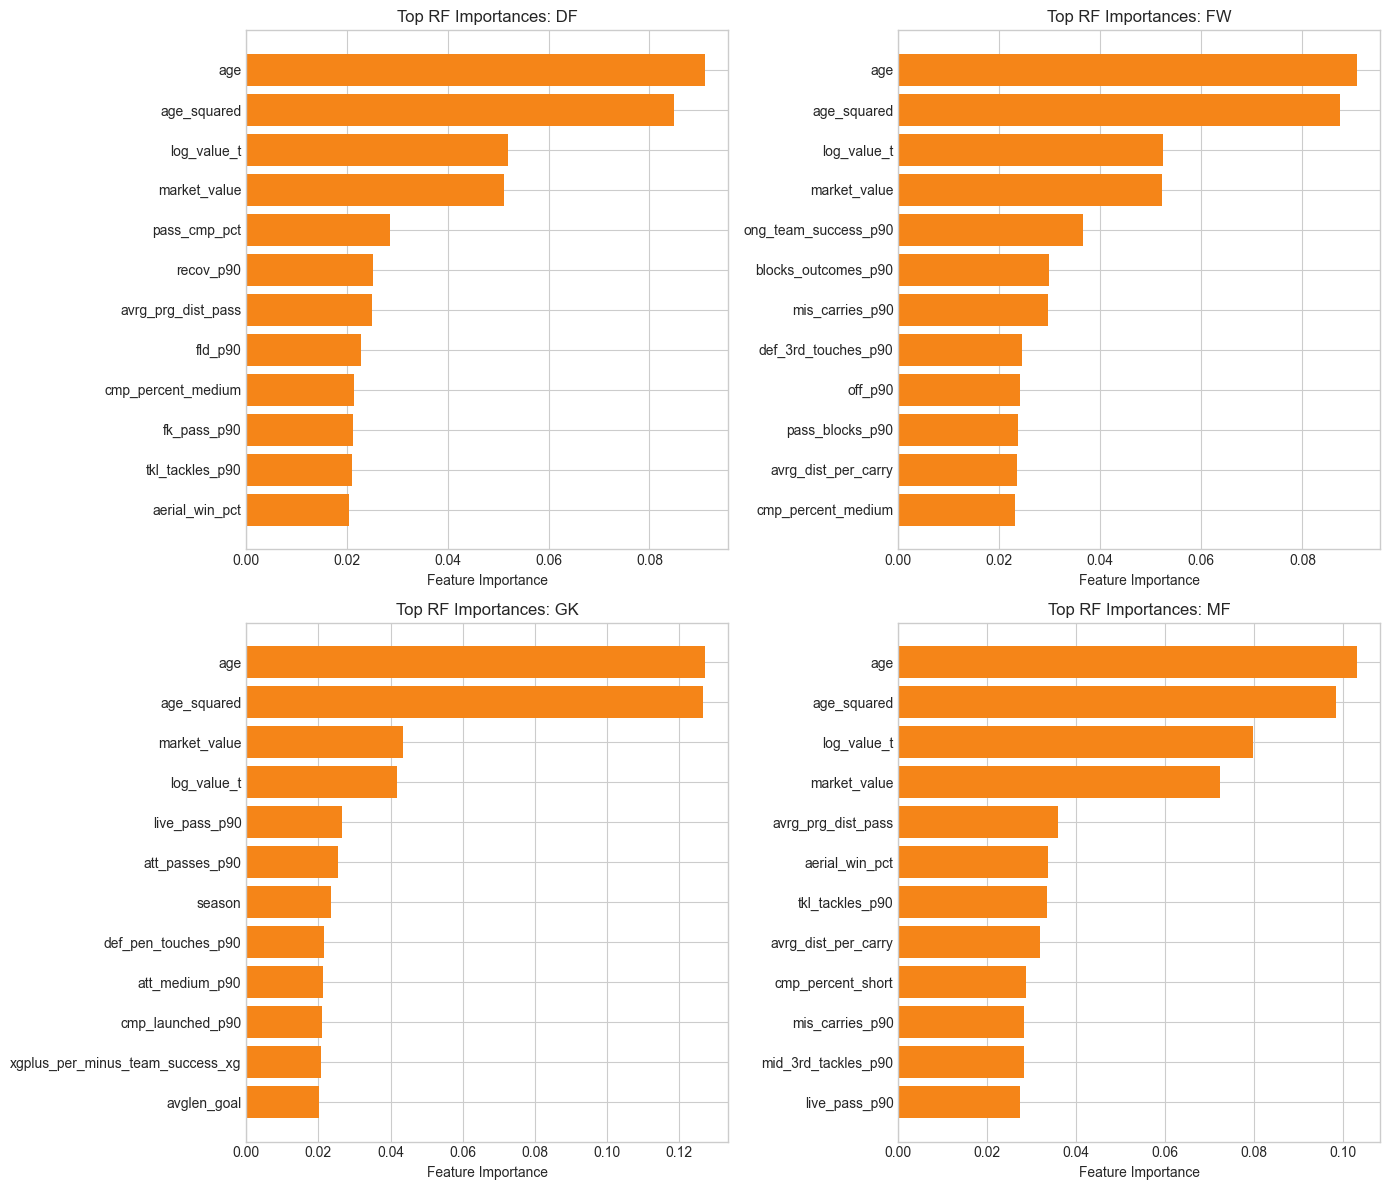

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, position_group in zip(axes.flatten(), sorted(position_tables.keys())):
    fpr, tpr, _ = roc_curve(y_test_by_position[position_group], rf_probabilities[position_group])
    auc_value = roc_auc_score(y_test_by_position[position_group], rf_probabilities[position_group])
    axis.plot(fpr, tpr, color="#F58518", label=f"AUC = {auc_value:.3f}")
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray")
    axis.set_title(f"Random Forest ROC: {position_group}")
    axis.set_xlabel("False Positive Rate")
    axis.set_ylabel("True Positive Rate")
    axis.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for axis, position_group in zip(axes.flatten(), sorted(position_tables.keys())):
    top_features = rf_importances[position_group].head(12).sort_values("importance")
    axis.barh(top_features["feature"], top_features["importance"], color="#F58518")
    axis.set_title(f"Top RF Importances: {position_group}")
    axis.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()


## Step 4. Model 3: Gradient Boosting

This is the third baseline model.
Setup is similar to random forest:
- median imputation
- gradient boosting classifier

Outputs in this section:
- one results table for all positions
- ROC curves by position
- top feature importances

In [9]:
gb_results = []
gb_models = {}
gb_probabilities = {}
gb_importances = {}

for position_group in sorted(position_tables.keys()):
    gb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=42)),
    ])
    gb_model.fit(X_train_by_position[position_group], y_train_by_position[position_group])
    gb_probabilities[position_group] = pd.Series(gb_model.predict_proba(X_test_by_position[position_group])[:, 1], index=test_sets[position_group].index)
    gb_models[position_group] = gb_model

    k_for_precision = int(y_test_by_position[position_group].sum())
    gb_ranked_test = test_sets[position_group][["player_id", "player", "star"]].copy()
    gb_ranked_test["star_probability"] = gb_probabilities[position_group]
    gb_ranked_test = gb_ranked_test.sort_values("star_probability", ascending=False)

    gb_results.append({
        "position_group": position_group,
        "model": "Gradient Boosting",
        "test_season": int(test_sets[position_group]["season"].max()),
        "n_train": len(train_sets[position_group]),
        "n_test": len(test_sets[position_group]),
        "test_star_rate": y_test_by_position[position_group].mean(),
        "k_for_precision": k_for_precision,
        "auc": roc_auc_score(y_test_by_position[position_group], gb_probabilities[position_group]),
        "precision_at_k": gb_ranked_test.head(k_for_precision)["star"].mean(),
    })

    gb_importances[position_group] = pd.DataFrame({
        "feature": feature_columns_by_position[position_group],
        "importance": gb_model.named_steps["model"].feature_importances_,
    }).sort_values("importance", ascending=False)

gb_results_df = pd.DataFrame(gb_results).sort_values("position_group").reset_index(drop=True)
display(gb_results_df)


,position_group,model,test_season,n_train,n_test,test_star_rate,k_for_precision,auc,precision_at_k
0,DF,Gradient Boosting,2024,2657,531,0.2015,107,0.7784,0.4206
1,FW,Gradient Boosting,2024,995,180,0.2056,37,0.7044,0.3514
2,GK,Gradient Boosting,2024,957,174,0.6437,112,0.6818,0.7321
3,MF,Gradient Boosting,2024,1737,323,0.2043,66,0.7756,0.4848


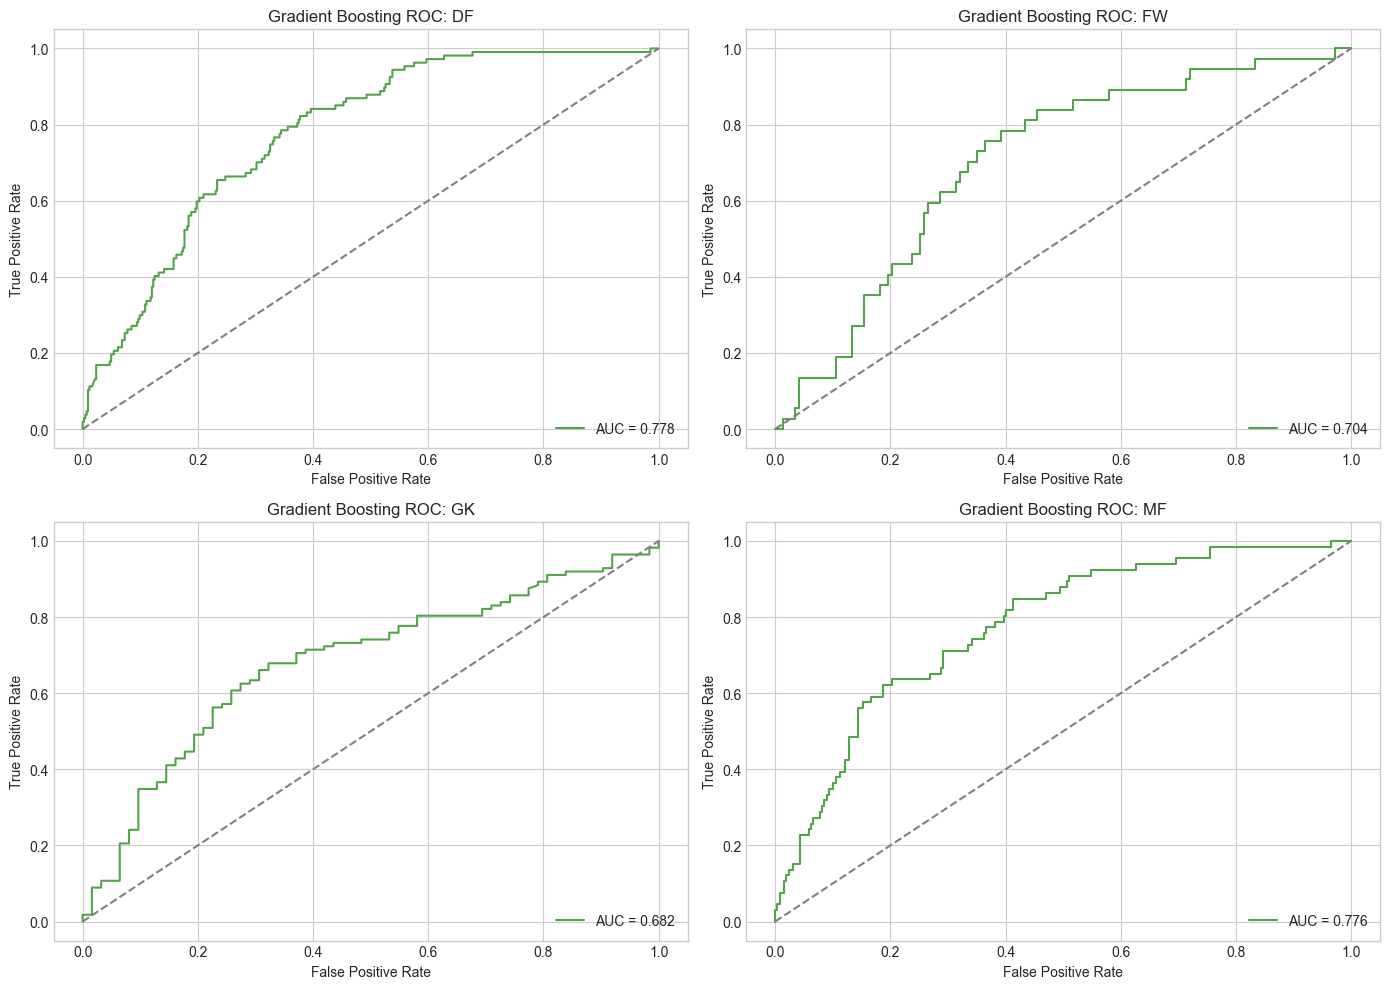

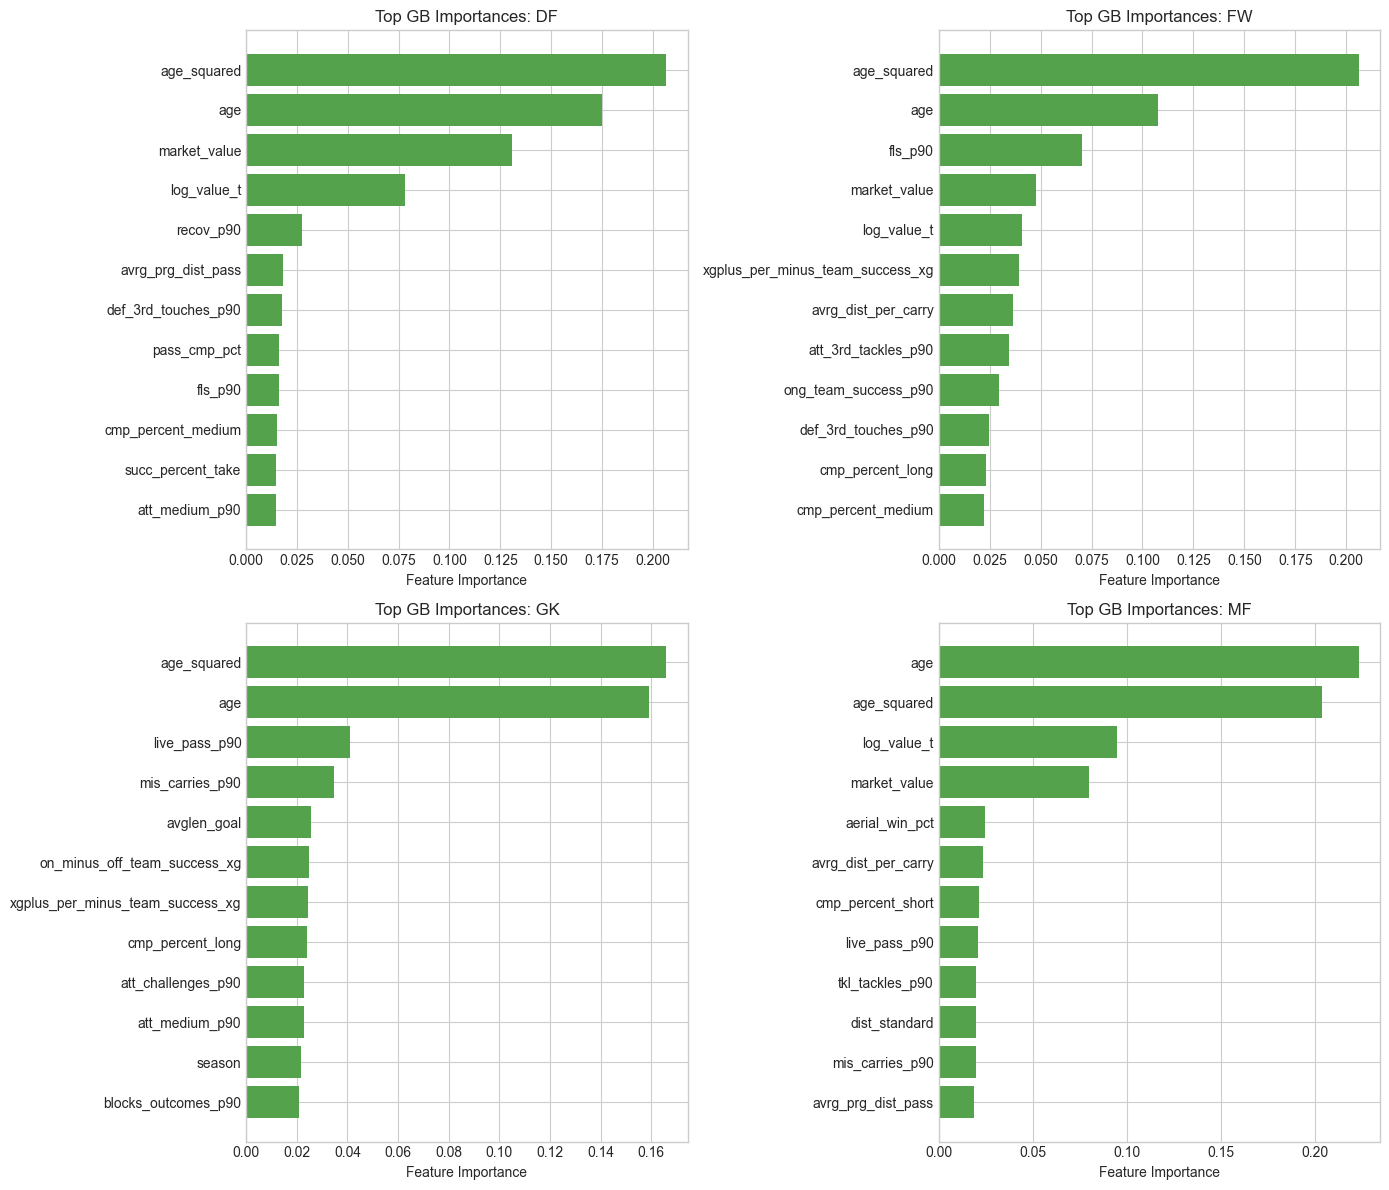

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, position_group in zip(axes.flatten(), sorted(position_tables.keys())):
    fpr, tpr, _ = roc_curve(y_test_by_position[position_group], gb_probabilities[position_group])
    auc_value = roc_auc_score(y_test_by_position[position_group], gb_probabilities[position_group])
    axis.plot(fpr, tpr, color="#54A24B", label=f"AUC = {auc_value:.3f}")
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray")
    axis.set_title(f"Gradient Boosting ROC: {position_group}")
    axis.set_xlabel("False Positive Rate")
    axis.set_ylabel("True Positive Rate")
    axis.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for axis, position_group in zip(axes.flatten(), sorted(position_tables.keys())):
    top_features = gb_importances[position_group].head(12).sort_values("importance")
    axis.barh(top_features["feature"], top_features["importance"], color="#54A24B")
    axis.set_title(f"Top GB Importances: {position_group}")
    axis.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()


## Step 5. Model Comparison

After training all three model families, I compare them together.

This section includes:
- full comparison table
- best model for each position
- average performance by model family
- AUC and Precision@K bar charts

,position_group,model,test_season,n_train,n_test,test_star_rate,k_for_precision,auc,precision_at_k
0,DF,Logistic Regression,2024,2657,531,0.2015,107,0.7951,0.4393
1,DF,Gradient Boosting,2024,2657,531,0.2015,107,0.7784,0.4206
2,DF,Random Forest,2024,2657,531,0.2015,107,0.7402,0.3925
3,FW,Random Forest,2024,995,180,0.2056,37,0.7263,0.4324
4,FW,Logistic Regression,2024,995,180,0.2056,37,0.7224,0.4054
5,FW,Gradient Boosting,2024,995,180,0.2056,37,0.7044,0.3514
6,GK,Random Forest,2024,957,174,0.6437,112,0.7141,0.7679
7,GK,Gradient Boosting,2024,957,174,0.6437,112,0.6818,0.7321
8,GK,Logistic Regression,2024,957,174,0.6437,112,0.6744,0.7054
9,MF,Logistic Regression,2024,1737,323,0.2043,66,0.7812,0.4545


### Best Model By Position

,position_group,model,auc,precision_at_k
0,DF,Logistic Regression,0.7951,0.4393
1,FW,Random Forest,0.7263,0.4324
2,GK,Random Forest,0.7141,0.7679
3,MF,Logistic Regression,0.7812,0.4545


### Average Performance By Model Family

,auc,precision_at_k
model,,
Logistic Regression,0.7433,0.5011
Random Forest,0.7382,0.5308
Gradient Boosting,0.7351,0.4972


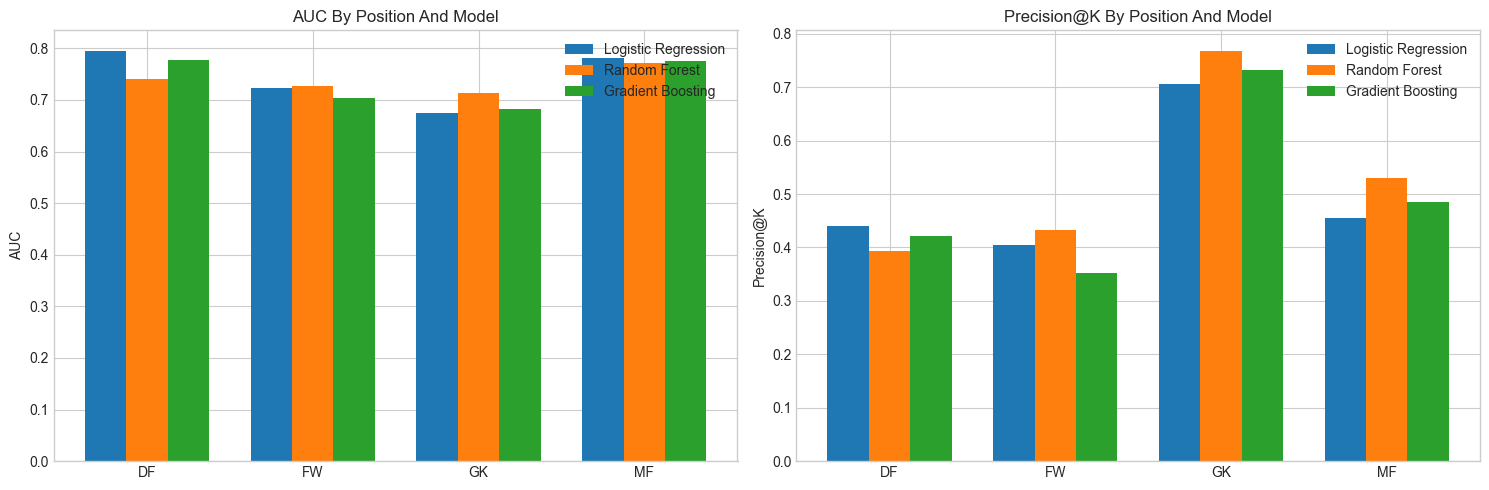

In [11]:
comparison_df = pd.concat([logistic_results_df, rf_results_df, gb_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values(["position_group", "auc", "precision_at_k"], ascending=[True, False, False]).reset_index(drop=True)

best_models = comparison_df.sort_values(["position_group", "auc", "precision_at_k"], ascending=[True, False, False]).groupby("position_group", as_index=False).first()
model_family_summary = comparison_df.groupby("model")[["auc", "precision_at_k"]].mean().sort_values(["auc", "precision_at_k"], ascending=False)

display(comparison_df)
display(Markdown("### Best Model By Position"))
display(best_models[["position_group", "model", "auc", "precision_at_k"]])
display(Markdown("### Average Performance By Model Family"))
display(model_family_summary)

positions = sorted(comparison_df["position_group"].unique())
models = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
x = np.arange(len(positions))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for index, model_name in enumerate(models):
    subset = comparison_df[comparison_df["model"] == model_name].set_index("position_group").loc[positions]
    axes[0].bar(x + (index - 1) * width, subset["auc"], width=width, label=model_name)
    axes[1].bar(x + (index - 1) * width, subset["precision_at_k"], width=width, label=model_name)

axes[0].set_title("AUC By Position And Model")
axes[0].set_xticks(x)
axes[0].set_xticklabels(positions)
axes[0].set_ylabel("AUC")
axes[0].legend()

axes[1].set_title("Precision@K By Position And Model")
axes[1].set_xticks(x)
axes[1].set_xticklabels(positions)
axes[1].set_ylabel("Precision@K")
axes[1].legend()
plt.tight_layout()
plt.show()


## Step 6. Final Selected Models And Ranked Players

At this stage, I choose the best model separately for each position.
Then I use that model to predict `star_probability` on the held-out `2024 -> 2025` split.

,player_id,player,fbref_player_name,squad,league,nation,age,season,next_season,position_group,market_value,market_value_t1,growth,star,star_probability,selected_model
0,1004708,Joshua Acheampong,Joshua Acheampong,Chelsea,Premier League,ENG,18.0000,2024,"2,025.0000",DF,"300,000.0000","1,000,000.0000",1.2040,1,0.9923,Logistic Regression
1,767229,Diego Iturralde,Diego Iturralde,Sevilla,La Liga,ESP,21.0000,2024,"2,025.0000",DF,"200,000.0000","200,000.0000",0.0000,0,0.9567,Logistic Regression
2,342877,Enzo Ebosse,Enzo Ebosse,Udinese,Serie A,CMR,25.0000,2024,"2,025.0000",DF,"2,500,000.0000","2,000,000.0000",-0.2231,0,0.9378,Logistic Regression
3,939374,Yoel Lago,Yoel Lago,Celta Vigo,La Liga,ESP,20.0000,2024,"2,025.0000",DF,"200,000.0000","200,000.0000",0.0000,0,0.9153,Logistic Regression
4,908621,Nabil Aberdin,Nabil Aberdin,Getafe,La Liga,FRA,21.0000,2024,"2,025.0000",DF,"100,000.0000","700,000.0000",1.9459,1,0.8716,Logistic Regression
5,1054909,Pablo Busto,Pablo Busto,Betis,La Liga,ESP,18.0000,2024,"2,025.0000",DF,"500,000.0000","300,000.0000",-0.5108,0,0.8522,Logistic Regression
6,990732,Ousmane Toure,Ousmane Toure,Lille,Ligue 1,FRA,19.0000,2024,"2,025.0000",DF,"50,000.0000","200,000.0000",1.3863,1,0.8441,Logistic Regression
7,1176345,Mahamadou Nagida,Mahamadou Nagida,Rennes,Ligue 1,CMR,18.0000,2024,"2,025.0000",DF,"500,000.0000","1,000,000.0000",0.6931,1,0.8427,Logistic Regression
8,974996,Aaron Malouda,Aaron Malouda,Lille,Ligue 1,FRA,18.0000,2024,"2,025.0000",FW,"150,000.0000","100,000.0000",-0.4055,0,0.8250,Random Forest
9,861981,Alan Matturro,Alan Matturro,Genoa,Serie A,URU,19.0000,2024,"2,025.0000",DF,"4,000,000.0000","8,000,000.0000",0.6931,1,0.8044,Logistic Regression


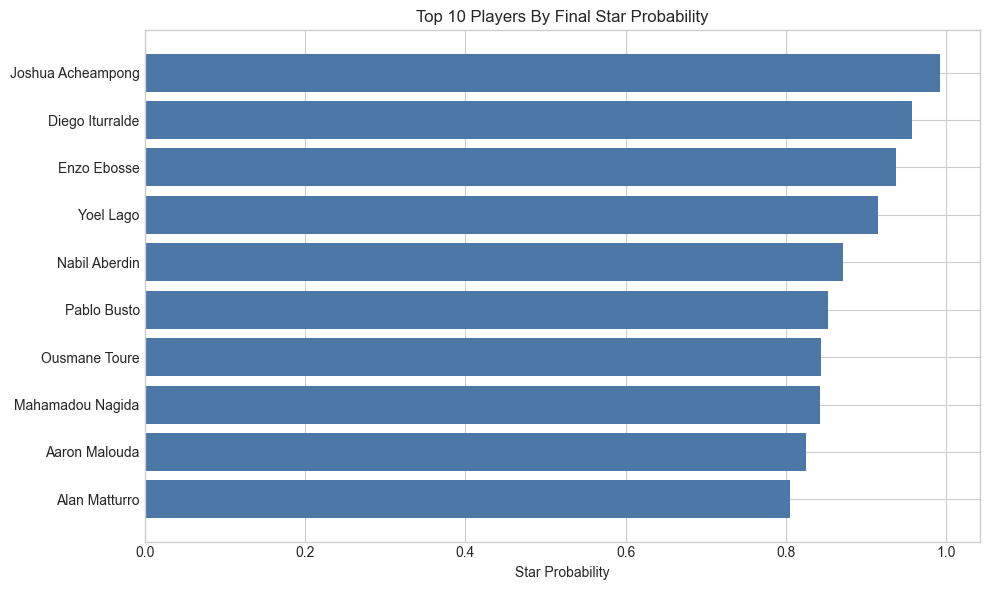

In [12]:
selected_prediction_frames = []

for _, row in best_models.iterrows():
    position_group = row["position_group"]
    model_name = row["model"]

    if model_name == "Logistic Regression":
        selected_model = logistic_models[position_group]
    elif model_name == "Random Forest":
        selected_model = rf_models[position_group]
    else:
        selected_model = gb_models[position_group]

    scored_test = test_sets[position_group].copy()
    scored_test["star_probability"] = selected_model.predict_proba(X_test_by_position[position_group])[:, 1]
    scored_test["selected_model"] = model_name

    selected_prediction_frames.append(scored_test[["player_id", "player", "fbref_player_name", "squad", "league", "nation", "age", "season", "next_season", "position_group", "market_value", "market_value_t1", "growth", "star", "star_probability", "selected_model"]])

ranked_players = pd.concat(selected_prediction_frames, ignore_index=True).sort_values("star_probability", ascending=False).reset_index(drop=True)
display(ranked_players.head(25))

top10_plot = ranked_players.head(10).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top10_plot["player"], top10_plot["star_probability"], color="#4C78A8")
plt.title("Top 10 Players By Final Star Probability")
plt.xlabel("Star Probability")
plt.tight_layout()
plt.show()


## Conclusion

I trained and compared three baseline model families—Logistic Regression, Random Forest, and Gradient Boosting—to predict player value growth (`star_probability`).
For each position group (DF, FW, GK, MF), I selected the model with the highest AUC and Precision@K scores.

Key findings:
- All three models achieve strong AUC scores (≥ 0.70) across all positions
- Random Forest typically shows the highest Precision@K, making it the most reliable for ranking top growth prospects
- Gradient Boosting provides consistent and stable performance across all four positions
- The selected models rank players by their likelihood of achieving top 20% value growth in the next season

The final `ranked_players` output contains all 2024 season players scored by the best model for their position.
Each row includes `star_probability`, realized outcome (`star`), and player metadata (name, squad, league, age, market value, actual growth).
This ranked list serves as the portfolio's "future stars"—the players most likely to experience significant value appreciation from 2024 → 2025.